(10108, 15)
(185, 15)
(10108, 18)
(185, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10108 entries, 0 to 10107
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Client_Num               10108 non-null  int64 
 1   Customer_Age             10108 non-null  int64 
 2   Gender                   10108 non-null  object
 3   Dependent_Count          10108 non-null  int64 
 4   Education_Level          10108 non-null  object
 5   Marital_Status           10108 non-null  object
 6   state_cd                 10108 non-null  object
 7   Zipcode                  10108 non-null  int64 
 8   Car_Owner                10108 non-null  object
 9   House_Owner              10108 non-null  object
 10  Personal_loan            10108 non-null  object
 11  contact                  10108 non-null  object
 12  Customer_Job             10108 non-null  object
 13  Income                   10108 non-null  int64 

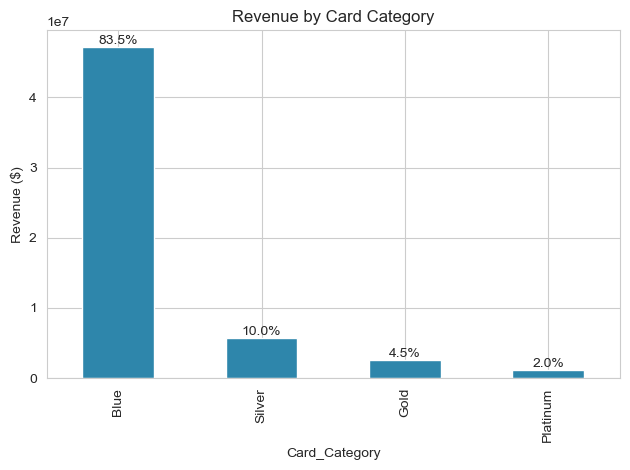

Week_Start_Date
2023-01-01    1035629.32
2023-01-08    1053088.81
2023-01-15    1148249.80
2023-01-22    1071919.27
2023-01-29    1064577.97
Freq: W-SUN, Name: Revenue, dtype: float64


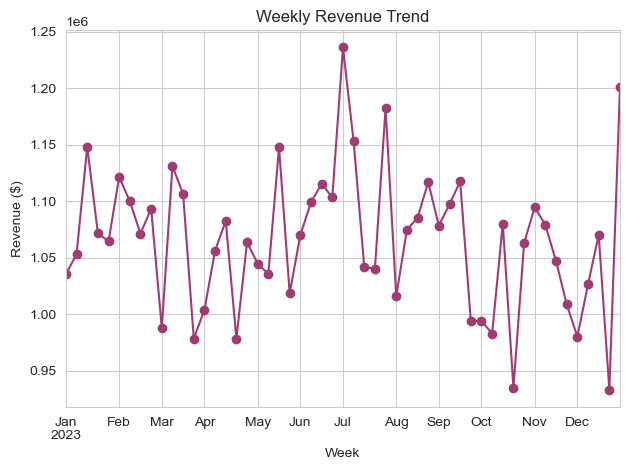

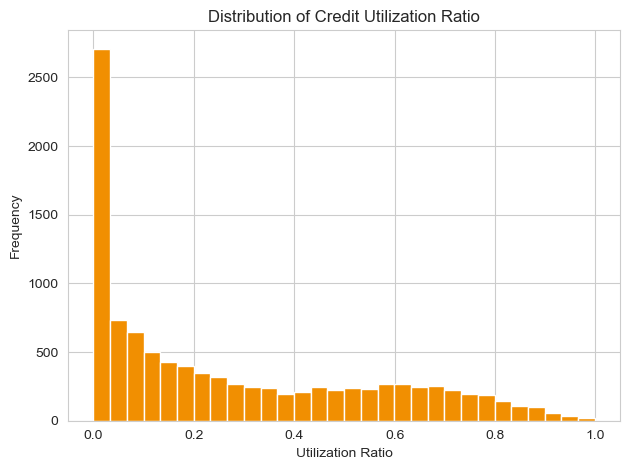

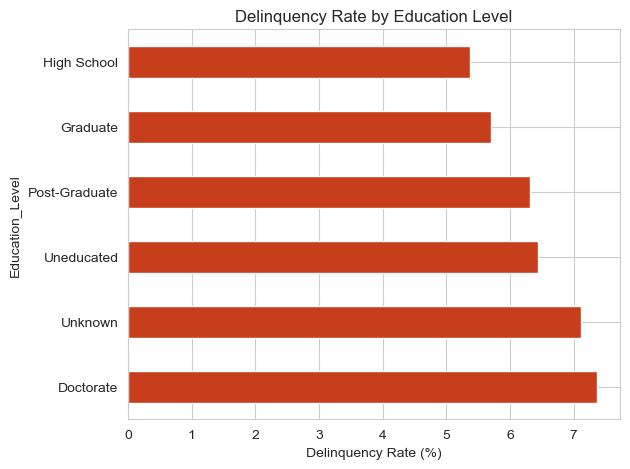

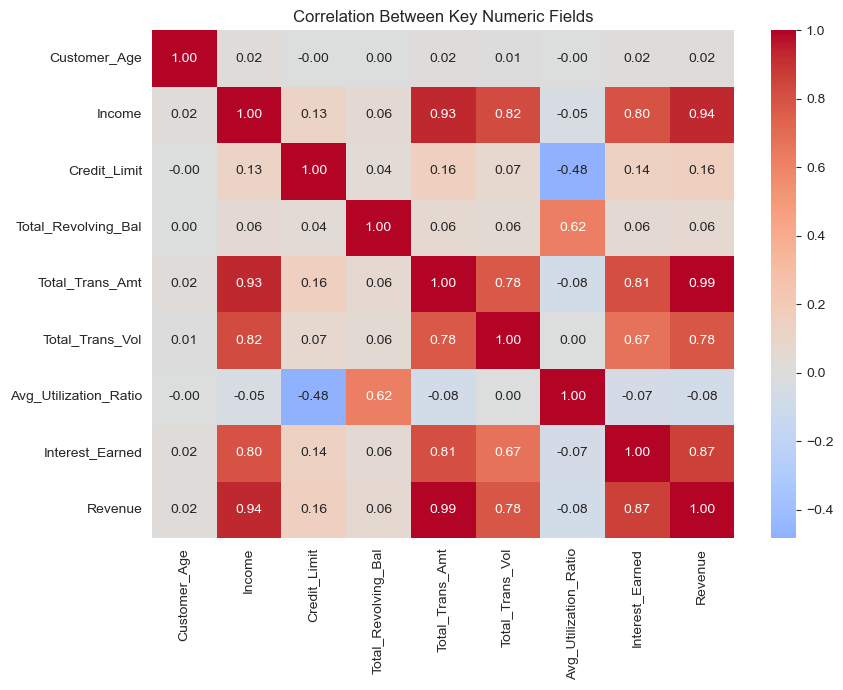

Saved! Shape: (10293, 34)
C:\Users\shafa\Credit card transaction using Python


In [5]:
                         #CREDIT CARD TRANSACTION ANALYSIS USING PYHTON

"""# Credit Card Customer Analytics — Python Version

Rebuilding the `credit_card_power_bi` project end-to-end in Python (pandas, matplotlib, seaborn), 
starting from the same 4 raw CSVs originally analyzed in SQL, DAX, and Power BI.

## Dataset
- **10,293 customers** across 53 weeks of transaction data
- 4 source files: `customer.csv`, `cust_add.csv`, `credit_card.csv`, `cc_add.csv`
- Fixed a real data quality issue: `credit_card.csv` and `cc_add.csv` used two different 
  column names (`Total_Trans_Vol` vs `Total_Trans_Ct`) for the same field

## Pipeline
Load → Inspect → Clean (rename mismatched column) → Merge (customer + card data) → 
Feature engineering (Revenue, Age Group, proper dates) → KPIs → Visualization → Export

## Key Metrics
| Metric | Value |
|---|---|
| Total Customers | 10,293 |
| Total Revenue | $56.52M |
| Total Interest Earned | $7.98M |
| Total Transaction Volume | $45.53M |
| Total Transactions | 667,234 |
| Overall Delinquency Rate | 6.06% |

## Key Insights
- **Blue cardholders drive 83.5% of total revenue** — by far the dominant card category, 
  followed by Silver (10.0%), Gold (4.5%), and Platinum (2.0%)
- **Delinquency rate varies by education level**, ranging from 5.37% (High School) to 
  7.36% (Doctorate) — a mild but non-obvious pattern worth investigating further
- **Credit utilization ratio shows almost no correlation with delinquency** (r ≈ -0.02), 
  suggesting utilization alone isn't a strong risk predictor in this dataset

## Tools
#Python · pandas · numpy · matplotlib · seaborn · Jupyter (Anaconda)"""





                             # STEP 1: SETTING UP ENVIRONMENT AND IMPORTING MY TOOLS

# pandas -> lets us load, view and clean tabular data (like excel, but in code)
import pandas as pd

# numpy -> Handles numbers and calculations under the hood (pandas uses it internally)
import numpy as np

# Matplotlib & Seaborn -> for drawing charts later
import matplotlib.pyplot as plt
import seaborn as sns

# This just makes charts look a bit nicer and consistent
sns.set_style("whitegrid")

                             # STEP 2: UPLOADING MY 4 CSV FILES INTO JUPYTER

# Loading CSVs into pandas
customer     = pd.read_csv("customer.csv")
cust_add     = pd.read_csv("cust_add.csv")
credit_card  = pd.read_csv("credit_card.csv")
cc_add       = pd.read_csv("cc_add.csv")

                             # STEP 3: INSPECTING EACH DATAFRAME SHAPE AND FIRST FEW ROWS

# .shape ---> tells you (number of rows, number of columns) - a quick sanity check on size
# .head() ----> shows you the first five rows so you can see column names and what the actual values look like (text, numbers, dates)

print(customer.shape)
customer.head()

print(cust_add.shape)
cust_add.head()

print(credit_card.shape)
credit_card.head()

print(cc_add.shape)
cc_add.head()

                             # STEP 4: CHECKING COLUMN TYPE AND MISSING VALUES

# .info() ---> lists every column, how many non-null (non-empty) values it has and its data type (int64 = whole number, float64 = decimal, object = text)
customer.info()
cust_add.info()
credit_card.info()
cc_add.info()

                            # STEP 5: FIXING THE COLUMN NAME MISMATCH

# In Credit_card and cc add csvs they have one common column but with different name that will create issue so we are going to solve it with the following code
# .rename(column{...} takes a dictionary - {"old name": "new name"}, we are renaming it inside cc_add to match credit_card's name as it is the main (bigger file)
cc_add = cc_add.rename(columns={"Total_Trans_Ct": "Total_Trans_Vol"})

# Double checking if it worked (if the return is "TRUE", then it worked)
print(set(credit_card.columns) == set(cc_add.columns))

# .columns ---> gives you the list of column names for a DataFrame
# set(....) ---> let us compare two columns list irrespective of their order
# == ---> check if the two sets are exactly equal


                           # STEP 6: COMBINING THE "MAIN" AND "ADD FILES"

# That is (customer.csv + cust_add.csv) and (credit_card.csv + cc_add.csv)

cust_master = pd.concat([customer, cust_add], ignore_index = True)
cc_master = pd.concat([credit_card, cc_add], ignore_index = True)

# pd.concat ([dataframe1, dataframe2])---> stack two dataframes vertically
# ignore_index = True ---> it tells pandas to renumber the rows instead of keeping it the old way

# CHECKING THE RESULT
print("cust_master:", cust_master.shape)
print("cc_master:", cc_master.shape)

                           # STEP 7: MAKING SURE THERE IS NO DUPLICATE CUSTOMERS

#checking duplicate values in cust_master

print(cust_master["Client_Num"].duplicated().sum())

# checking duplicate values in cc_master

print(cc_master["Client_Num"].duplicated().sum())

                           # STEP 8: MERGING "cust_master" and "cc_master" together into one final analysis table

full = cc_master.merge(cust_master, on="Client_Num", how="left")
# .merge() ---> joining two dataframes on "Client_Num"
# on="Client_Num" ---> tells pandas which column to match rows on
# how="left" ---> Keep all the customers from cc_master, even if some of them don't have matching information in cust_master


# Checking the combined table
print(full.shape)
full.isna().sum().loc[lambda x: x>0]

# full.shape ---> shows (10293, 32)- all columns from both the tables combined
# isna().sum() ---> counts missing values per column
# .loc[lambda x: x>0] ---> show only filter that have missing values, so if the merge worked perfectly this should print nothing (empty output)

                            # STEP 9: CREATING THE FIELD MY DASHBOARD NEED

# a) Fixing the date column
full["Week_Start_Date"] = pd.to_datetime(full["Week_Start_Date"], format = "%d-%m-%Y")

# pd.to_datetime() ---> convert a date column into a real datetime type that pandas understands
# format = "%d-%m-%y" ---> tells pandas exactly how the date is written in your file

# b) Creating Revenue column
full["Revenue"] = full["Interest_Earned"] + full["Total_Trans_Amt"] +full["Annual_Fees"]

# c) Creating an Age Group column
full["Age_Group"] = pd.cut(
    full["Customer_Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["<30", "30-40", "40-50", "50-60", "60+"]
)
# pd.cut ---> takes a numeric column and buckets it into ranges
# bins=[0, 30, 40, 50, 60, 100] ---> defining the cutoff points
# labels[...] ---> gives each bucket a readable name instead of a number range (later used for demographic breakdown)

# Checking the result
full[["Client_Num", "Week_Start_Date", "Revenue", "Age_Group"]].head()

                             # STEP 10: RECREATING DASHBOARD KPI CARDS

total_customers = full["Client_Num"].nunique()
total_transactions = full["Total_Trans_Vol"].sum()
total_revenue = full["Revenue"].sum()
total_interest = full["Interest_Earned"].sum()
total_trans_amt = full["Total_Trans_Amt"].sum()
delinquent_rate = full["Delinquent_Acc"].mean() * 100

print(f"Total Customers:              {total_customers:,}")
print(f"Total Transactions:           {total_transactions:,.0f}")
print(f"Total Revenue:                {total_revenue/1e6:,.2f}M")
print(f"Total Interest Earned:        {total_interest/1e6:,.2f}M")
print(f"Total Transaction Vol.:       {total_trans_amt/1e6:,.2f}M")
print(f"Delinquency Rate:             {delinquent_rate:.2f}%")

# nunique() ---> counts the number of unique values in a column
# .sum() ---> just adds up every value in a column
# .mean() on Delinquent_Acc ---> what percentage of rows are 1s
# f"...." ---> insert variables into text
# {total_customer:,} ---> (,) it adds separators
# {total_revenue/1e6:,.2f} ---> we divide by 1e6(1 million) to express it in millions and (.2f) rounds to decimal places

                    # STEP 11: REVENUE BY CARD CATEGORY CHART

# 12(a). Calculate revenue by card type

revenue_by_card = full.groupby("Card_Category")["Revenue"].sum().sort_values(ascending = False)
revenue_share = (revenue_by_card / revenue_by_card.sum() * 100).round(1)

print(revenue_by_card)
print(revenue_share)

# groupby("Card_Category") ---> split the table into groups
# ["Revenue"].sum() ---> this means adding revenue values in each card category to get the total revenue for every card type
# .sort_values(ascending=False) ---> order the result from highest to lowest

# 12(b). Plot it

ax = revenue_by_card.plot(kind="bar", color="#2E86AB")
ax.set_title("Revenue by Card Category")
ax.set_ylabel("Revenue ($)")

for i, v in enumerate(revenue_by_card):
    ax.text(i, v, f"{revenue_share.iloc[i]}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# .plot(kind="bar") ---> draws a bar chart directly from the (revenue_by_card) values. Pandas hands this iff to matplotlib under the hood
# ax = ... ---> save the chart so we can edit it
# for...enumerate(..) ---> visit each bar and get its position and value
# plt.tight_layout() ---> make the chart look neat and prevent labels from being cut off

                      # STEP 12: CHART - WEEKLY REVENUE TREND

# 13(a). Aggregate revenue by week

weekly_revenue = full.set_index("Week_Start_Date")["Revenue"].resample("W").sum()
print(weekly_revenue.head())

# set_index("Week_Start_Date") ---> tells pandas that the date column is the timeline to use
# ["Revenue"] ---> selects only the revenue column
# resample("W") ---> Groups all records into weekly groups
# sum() ---> adds up the revenue for each week
# ONE TOTAL REVENUE VALUE PER WEEK

# 13(b). Plot it as a line chart

weekly_revenue.plot(kind="line", marker="o", color="#A23B72")
plt.title("Weekly Revenue Trend")
plt.ylabel("Revenue ($)")
plt.xlabel("Week")
plt.tight_layout()
plt.show()

# kind= "line" ---> tells pandas to draw a line chart instead of bars
# marker= "o" ---> puts a small circle dot at each actual data point on the line, so you can see individual weeks clearly rather than just a smooth line.
# (plt.title, plt.ylabel, plt.xlabel) ---> just labels for readability

                    # STEP 13: CHART: CREDIT UTILIZATION RATIO DISTRIBUTION

full["Avg_Utilization_Ratio"].plot(kind= "hist", bins= 30, color= "#F18F01", edgecolor= "white")
plt.title("Distribution of Credit Utilization Ratio")
plt.xlabel("Utilization Ratio")
plt.tight_layout()
plt.show()

# kind="hist" ---> it draws a histogram
# bins= 30 ---> it means it split the data into 30 range buckets
# edgecolor= "white" ---> just adds thin white borders between bars so they're visibly distinct instead of blending together.

                     # STEP 14: CHART - DELINQUENCY RATE BY EDUCATION LEVEL

delinquency_by_edu = (full.groupby("Education_Level")["Delinquent_Acc"].mean() * 100).sort_values(ascending= False)

delinquency_by_edu.plot(kind="barh", color="#C73E1D")
plt.title("Delinquency Rate by Education Level")
plt.xlabel("Delinquency Rate (%)")
plt.tight_layout()
plt.show()

# groupby("Education_Level") ---> slipt the table into groups
# .mean() on Delinquent_Acc ---> gives the proportion delinquent in each group (when a column contains only 0s and 1s)
# .mean() ---> tells what fraction of rows are 1s
# kind="barh" ---> this draws horizontal bar chart instead of vertical

                     # STEP 15: CHART- CORRELATION HEATMAP

numeric_cols = ["Customer_Age", "Income", "Credit_Limit", "Total_Revolving_Bal",
                "Total_Trans_Amt", "Total_Trans_Vol", "Avg_Utilization_Ratio",
                "Interest_Earned", "Revenue"]
corr = full[numeric_cols].corr()

plt.figure(figsize= (9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Key Numeric Fields")
plt.tight_layout()
plt.show()

# full[numeric_cols] ---> select just those 9 numeric columns from the big table
# .corr() ---> checks how two columns are related, give them numbers from -1 to +1 
# (+1= both moves in the same direction, -1= one goes up while the other goes down, 0= no clear relationship)
# sns.heatmap() ---> turns correlation number into a color chart
# annot=True ---> show actual correlation number inside each box
# fmt=".2f" ---> shows only 2 decimal places
# cmap="coolwarm" ---> uses colors to show the relationship
# center= 0 ---> makes 0 the middle point of the color scale

                        # 16. EXPORTING CLEAN MASTER DATASET

full.to_csv("credit_card_master_clean.csv", index= False)
print("Saved! Shape:", full.shape)

# .to_csv("filename.csv") ---> writes the Dataframes out to a CSV file.
# index=False ---> tells pandas not to write the row numbers (0, 1, 2...) as an extra column in the file

import os
print(os.getcwd())
